# Indian Tech Job Market 2026: Exploratory Data Analysis & Insights

### Project Overview
This notebook presents a comprehensive Exploratory Data Analysis (EDA) of the Indian tech job market in 2026. Using a dataset of over 23,000+ job listings, we explore salary trends, hiring hubs, demand for different roles, experience tiering, work mode preferences, and the premium associated with key skills.

### Dataset Metadata
- **Total Postings:** 23,201
- **Features:** 32 columns containing job metadata, salary details, required skills, company ratings, work modes, and cities.
- **Goal:** Uncover key patterns in tech hiring in India and address specific business questions regarding high-paying cities, skill premiums, remote work trends, fresher opportunities, and leading ML recruiters.

---

## 1. Importing Libraries
In this step, we import the core Python libraries required for data manipulation and visualization:
- `pandas` for handling tabular data structures (DataFrames).
- `numpy` for efficient mathematical and numerical array operations.
- `matplotlib.pyplot` and `seaborn` for generating statistical visualizations and plots.
- `wordcloud` for visualizing text data frequencies in a word cloud.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## 2. Loading the Dataset
We load the tech jobs dataset (`indian_tech_jobs_2026.csv`) from the local workspace. This dataset contains raw and cleaned features detailing the hiring landscape of 2026.


In [3]:
df = pd.read_csv(r'C:\Users\hussa\Downloads\Indian Tech Job Market 2026  23K+ Records\indian_tech_jobs_2026.csv')

## 3. Data Inspection and Exploration
We begin by inspecting the first few records using `df.head()` to understand the row structure, check the column alignments, and observe the formatting of raw vs. cleaned fields.


In [4]:
df.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


### 3.1. Visualizing End of DataFrame
We check `df.tail` to inspect the last few records and ensure there are no formatting anomalies or truncated columns at the end of the file.


In [5]:
df.tail

<bound method NDFrame.tail of        job_id                                        job_title  \
0           1                                   Data Scientist   
1           2                                   Data Scientist   
2           3                         Analytics Data Scientist   
3           4                                   Data Scientist   
4           5             Sr. Artificial Intelligence Engineer   
...       ...                                              ...   
23196   23197                       Python Developer-Hyderabad   
23197   23198                                 Python Developer   
23198   23199  Walk in Interview Python Developer II Hyderabad   
23199   23200                                 Python Developer   
23200   23201                                 Python Developer   

                          company_name  company_rating  \
0                                Cisco             4.1   
1                      Caterpillar Inc             4.1   
2  

### 3.2. Technical and Schema Summary
We call `df.info()` to view the dataset's schema. This includes column names, count of non-null values, data types (integer, float, object, boolean), and memory usage.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               23201 non-null  int64  
 1   job_title            23201 non-null  object 
 2   company_name         23201 non-null  object 
 3   company_rating       23201 non-null  float64
 4   location             23201 non-null  object 
 5   scraped_city         23201 non-null  object 
 6   role_category        23201 non-null  object 
 7   experience_raw       23201 non-null  object 
 8   experience_min_yrs   23201 non-null  float64
 9   experience_max_yrs   23201 non-null  float64
 10  salary_raw           23201 non-null  object 
 11  salary_min_lpa       23201 non-null  float64
 12  salary_max_lpa       23201 non-null  float64
 13  salary_disclosed     23201 non-null  bool   
 14  skills_required      23201 non-null  object 
 15  skills_count         23201 non-null 

### 3.3. Statistical Summary
We call `df.describe()` to generate summary statistics for numerical features, highlighting central tendency, dispersion, and min/max ranges for ratings, experience years, and salaries.


In [7]:
df.describe()

,job_id,company_rating,experience_min_yrs,experience_max_yrs,salary_min_lpa,salary_max_lpa,skills_count,salary_midpoint_lpa,days_since_posted
count,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000
mean,11601.000000,3.586449,4.135080,7.829059,1.383952,2.271790,7.604198,1.827872,15.698935
std,6697.696134,0.514250,2.933976,3.946834,4.841570,7.469383,1.456530,6.109373,7.575881
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5801.000000,3.400000,2.000000,5.000000,0.000000,0.000000,8.000000,0.000000,7.000000
50%,11601.000000,3.600000,4.000000,8.000000,0.000000,0.000000,8.000000,0.000000,21.000000
75%,17401.000000,3.800000,6.000000,10.000000,0.000000,0.000000,8.000000,0.000000,21.000000
max,23201.000000,5.000000,25.000000,31.000000,85.000000,90.000000,8.000000,87.500000,90.000000


### 3.4. Checking for Missing (Null) Values
We check for missing data using `df.isnull().sum()`. Identifying null values helps us decide if imputation, dropping, or special handling is necessary. As we can see, only `job_url` has a negligible count of null values, which has no bearing on our analysis.


In [8]:
df.isnull().sum()

job_id                  0
job_title               0
company_name            0
company_rating          0
location                0
scraped_city            0
role_category           0
experience_raw          0
experience_min_yrs      0
experience_max_yrs      0
salary_raw              0
salary_min_lpa          0
salary_max_lpa          0
salary_disclosed        0
skills_required         0
skills_count            0
job_description         0
posted_date_raw         0
work_mode               0
company_size_bucket     0
job_url                53
data_source             0
scraped_at              0
salary_tier             0
experience_tier         0
is_senior               0
primary_city            0
skill_domain            0
salary_midpoint_lpa     0
days_since_posted       0
is_fresher_friendly     0
salary_negotiable       0
dtype: int64

### 3.5. Duplicate Listings Check
We verify the presence of duplicate job listings in the dataset. A value of 0 indicates that every listing is unique based on all fields.


In [9]:
df.duplicated().sum()

np.int64(0)

### 3.6. Dataset Shape Check
We verify the dimensions of the dataset. It contains 23,201 rows (postings) and 32 columns (features).


In [10]:
df.shape

(23201, 32)

### 3.7. Cardinality of Features (Unique Values)
We check the number of unique values in each column to understand their cardinality. Columns with low unique counts (e.g. `role_category`, `work_mode`) are prime candidates for grouping and categorical analysis.


In [11]:
df.nunique()

job_id                 23201
job_title              13128
company_name            6993
company_rating            41
location                1565
scraped_city              11
role_category              6
experience_raw           238
experience_min_yrs        23
experience_max_yrs        29
salary_raw               476
salary_min_lpa            72
salary_max_lpa           100
salary_disclosed           2
skills_required        19185
skills_count               9
job_description        18306
posted_date_raw           47
work_mode                  3
company_size_bucket        3
job_url                21070
data_source                1
scraped_at                 1
salary_tier                6
experience_tier            5
is_senior                  2
primary_city             198
skill_domain               5
salary_midpoint_lpa      169
days_since_posted         13
is_fresher_friendly        2
salary_negotiable          1
dtype: int64

## 4. Univariate Analysis: Categorical Features

### 4.1. Role Category Distribution
We plot the distribution of job counts across major tech role categories. This visualization identifies which roles are in highest demand in the market.


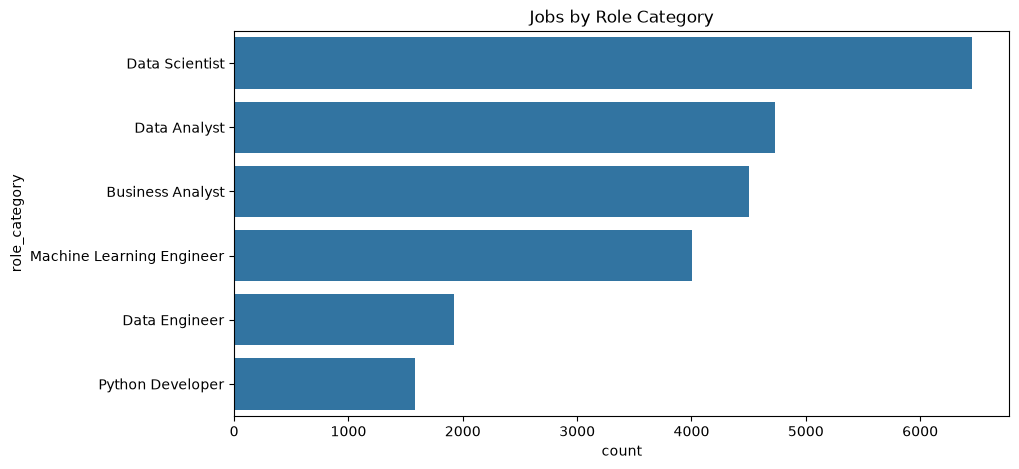

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(y="role_category",
              data=df,
              order=df.role_category.value_counts().index)

plt.title("Jobs by Role Category")
plt.show()

### 4.2. Distribution of Primary Hiring Cities
We visualize the count of job postings across various cities to locate the major tech hiring hubs in India.


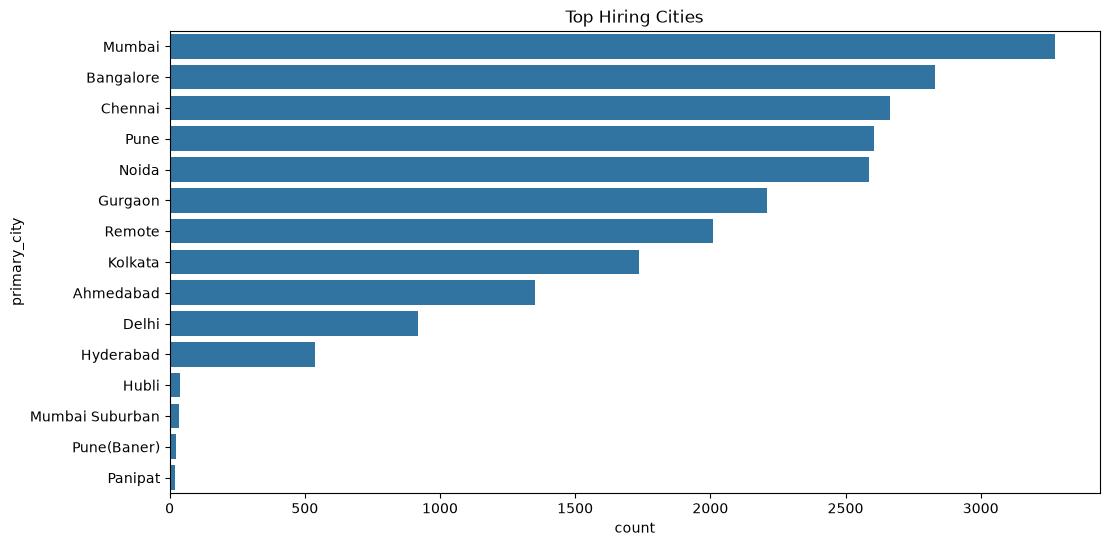

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(y="primary_city",
              data=df,
              order=df.primary_city.value_counts().head(15).index)

plt.title("Top Hiring Cities")
plt.show()


### 4.3. Workplace Policies: Remote vs. Hybrid vs. On-site
We plot the distribution of work modes to understand the industry standards regarding work-from-home, hybrid, and in-office models in 2026.


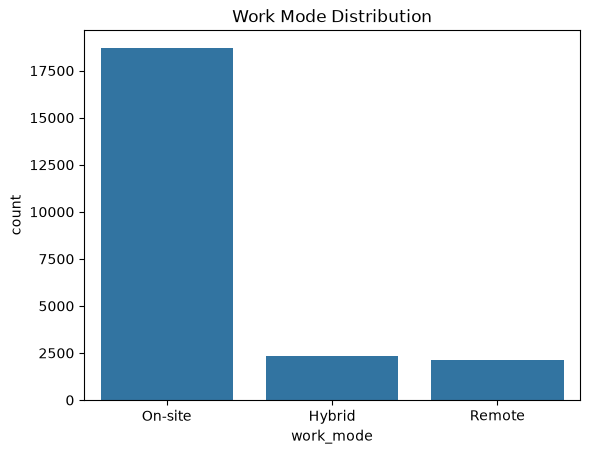

In [14]:
sns.countplot(x="work_mode", data=df)

plt.title("Work Mode Distribution")
plt.show()

### 4.4. Distribution of Salary Tiers
We visualize how job listings are grouped across predefined salary brackets (tiers). Note the high volume of "Undisclosed" salaries.


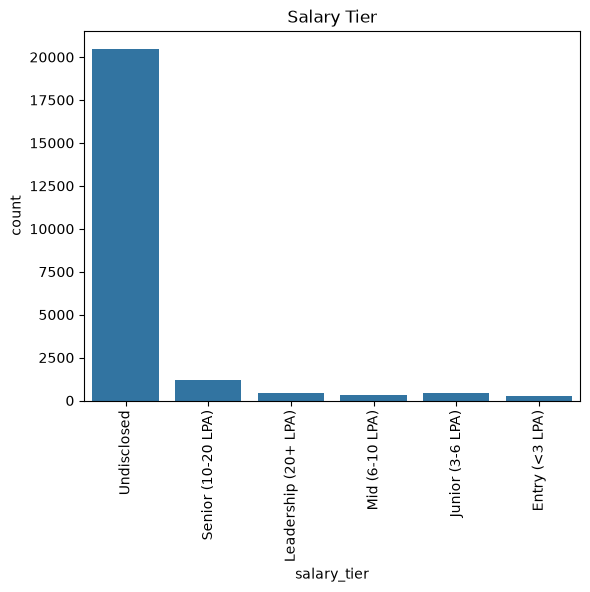

In [15]:
sns.countplot(x="salary_tier", data=df)

plt.title("Salary Tier")
plt.xticks(rotation=90)
plt.show()


### 4.5. Required Experience Tiers
We plot the distribution of experience tiers required by employers, classifying roles from freshers to lead architects.


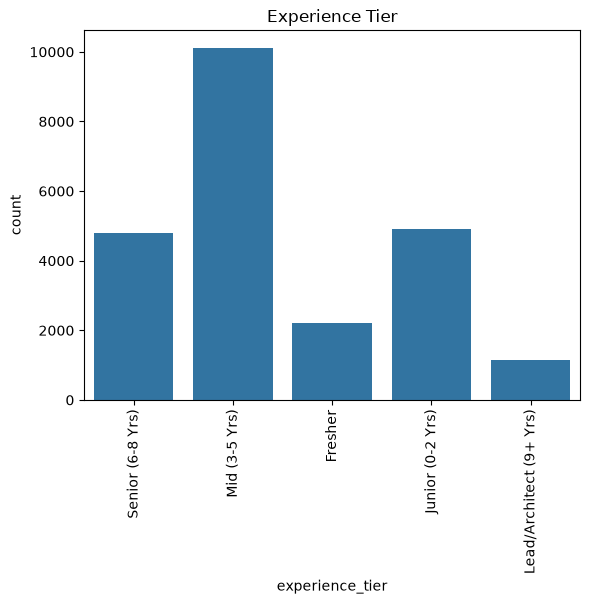

In [16]:
sns.countplot(x="experience_tier", data=df)

plt.title("Experience Tier")
plt.xticks(rotation=90)
plt.show()

## 5. Univariate Analysis: Numerical Features

### 5.1. Distribution of Company Ratings
We plot a histogram of company ratings to evaluate standard employee sentiments. The ratings form a bell-curve centered around a healthy average of 3.58.


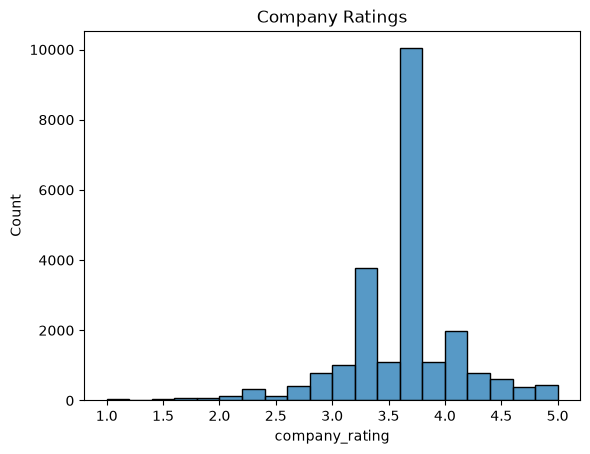

In [17]:
sns.histplot(df["company_rating"], bins=20)

plt.title("Company Ratings")
plt.show()

### 5.2. Distribution of Salary Midpoint (LPA)
We plot the distribution of salary midpoints (in Lakhs Per Annum). This shows the pricing distribution for tech talent, with a prominent spike at 0 representing undisclosed compensation.


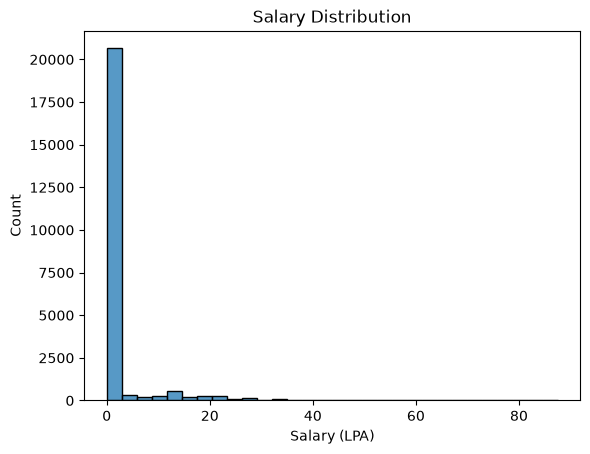

In [18]:
sns.histplot(df["salary_midpoint_lpa"], bins=30)

plt.title("Salary Distribution")
plt.xlabel("Salary (LPA)")
plt.show()

### 5.3. Distribution of Minimum Required Experience
We plot the minimum experience requirements to see the entry barrier (in years) across the industry.


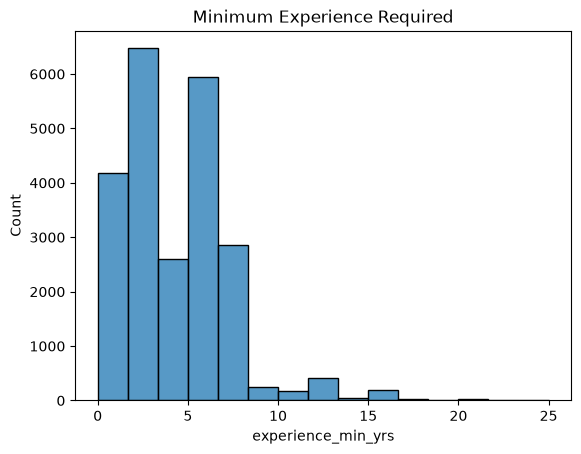

In [19]:
sns.histplot(df["experience_min_yrs"], bins=15)

plt.title("Minimum Experience Required")
plt.show()

## 6. Bivariate and Multivariate Data Analysis

### 6.1. Experience vs. Salary Midpoint (LPA)
We use a scatter plot to analyze how the minimum experience requirements relate to the salary midpoint. We expect a positive correlation between experience and compensation.


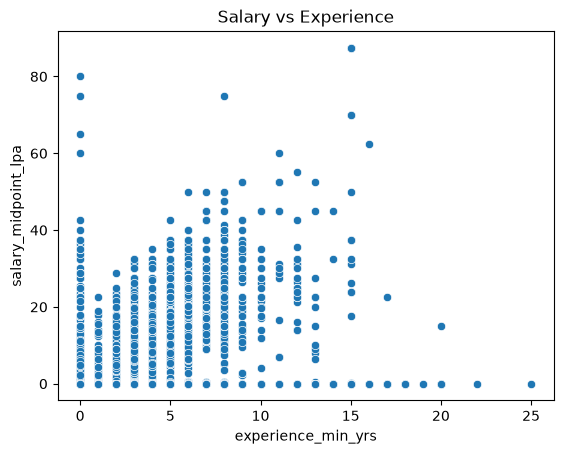

In [20]:
sns.scatterplot(
    x="experience_min_yrs",
    y="salary_midpoint_lpa",
    data=df
)

plt.title("Salary vs Experience")
plt.show()

### 6.2. Salary Midpoint vs. Workplace Policy
We generate a box plot comparing salary midpoint distributions across Remote, Hybrid, and On-site working models. This helps determine if remote or hybrid roles carry a salary premium or discount.


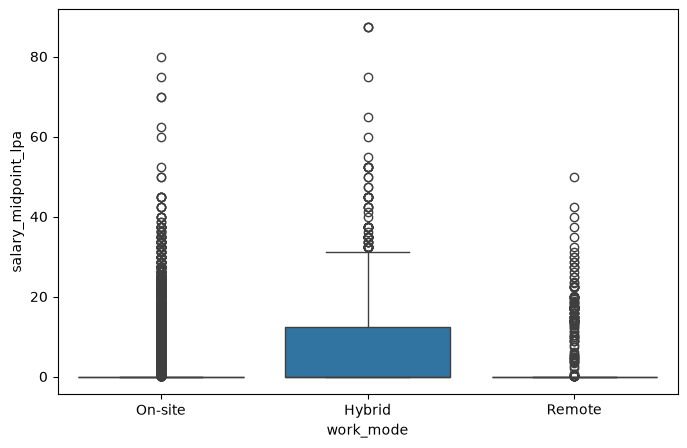

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="work_mode",
    y="salary_midpoint_lpa",
    data=df
)

plt.show()

### 6.3. Salary Midpoint across Role Categories
We use box plots to compare the salary spreads across different career roles, illustrating which specializations command higher pay.


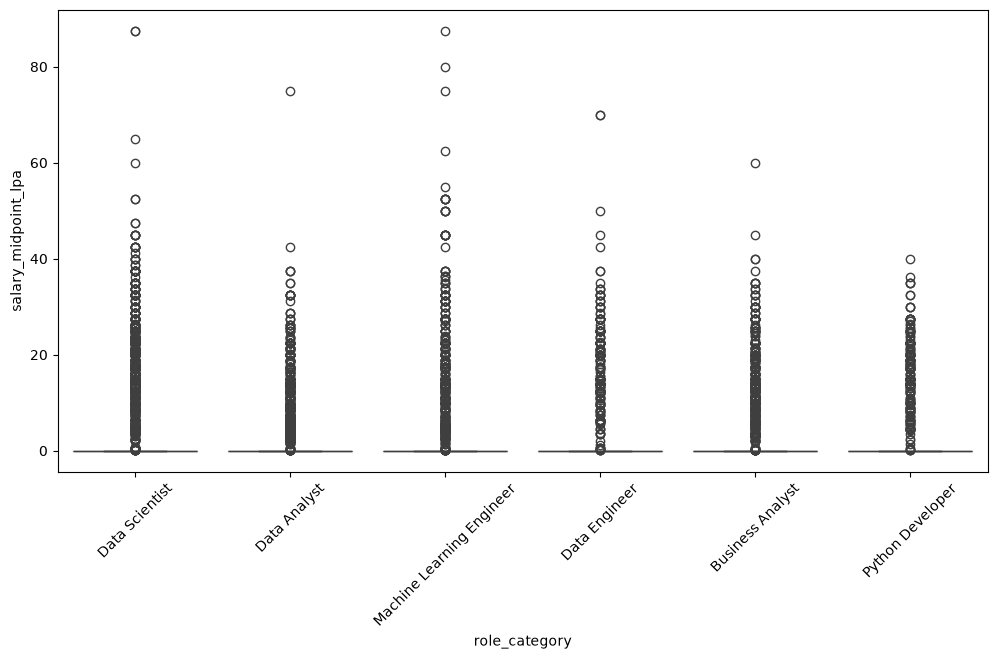

In [22]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="role_category",
    y="salary_midpoint_lpa",
    data=df
)

plt.xticks(rotation=45)
plt.show()

### 6.4. Company Rating vs. Salary Midpoint
We map company ratings against salary midpoints to see if highly rated companies pay higher salaries.


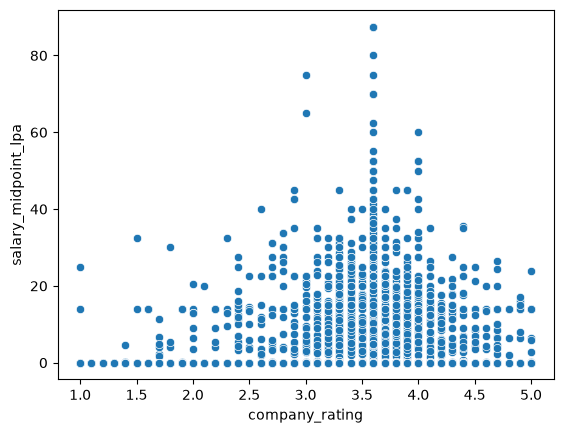

In [23]:
sns.scatterplot(
    x="company_rating",
    y="salary_midpoint_lpa",
    data=df
)

plt.show()

### 6.5. Distribution of Company Size Buckets
We plot the company size categories to see the distribution of hiring firms, from startups and mid-market players to large enterprises.


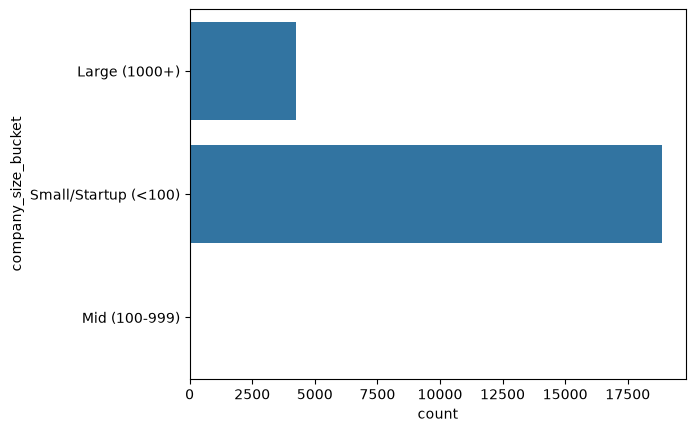

In [24]:
sns.countplot(
    y="company_size_bucket",
    data=df
)

plt.show()

### 6.6. Top 20 Tech Recruiters in India
We visualize the top 20 companies posting the most tech jobs in our dataset to identify the most active hiring firms in 2026.


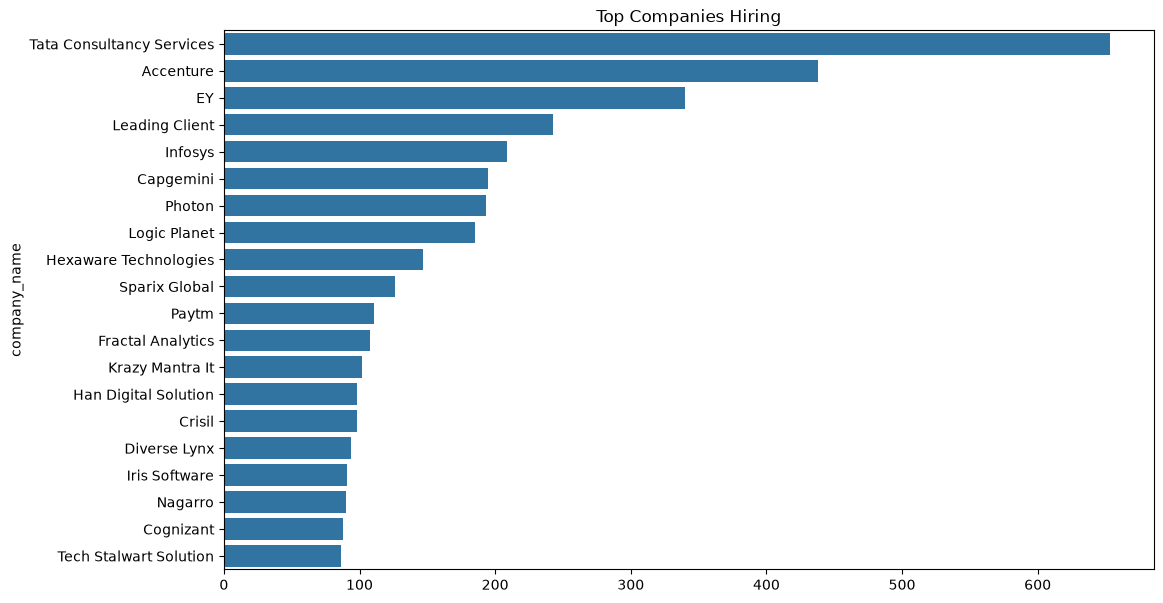

In [25]:
top = df.company_name.value_counts().head(20)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top.values,
    y=top.index
)

plt.title("Top Companies Hiring")
plt.show()

### 6.7. Analysis of Fresher-Friendly Jobs
We analyze the portion of tech jobs classified as fresher-friendly to gauge opportunities available to entry-level candidates.


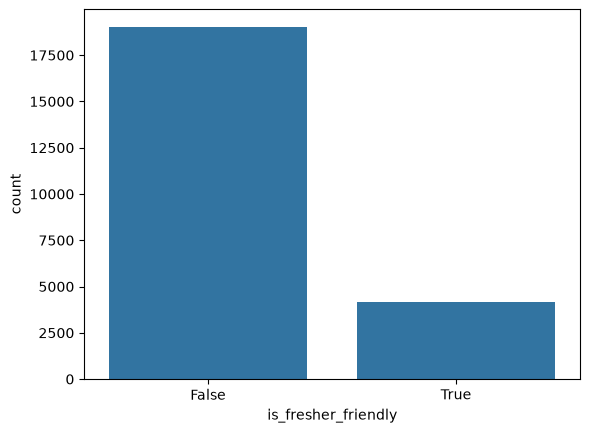

In [26]:
sns.countplot(
    x="is_fresher_friendly",
    data=df
)

plt.show()

### 6.8. Seniority Classifications
We evaluate the proportion of jobs designated specifically for senior-level candidates.


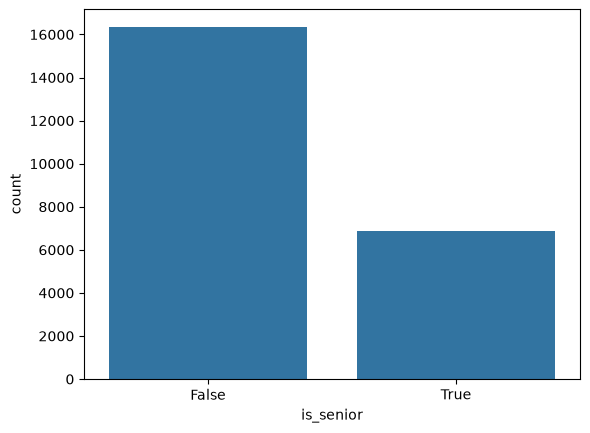

In [27]:
sns.countplot(
    x="is_senior",
    data=df
)

plt.show()

### 6.9. Salary Negotiability Rate
We plot the percentage of job listings that mention salary navigability or negotiability to understand flexibility during job offers.


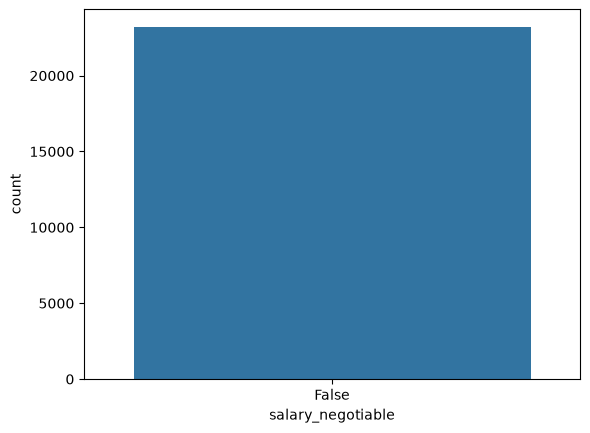

In [28]:
sns.countplot(
    x="salary_negotiable",
    data=df
)

plt.show()

### 6.10. Distribution of Skills Count per Posting
We analyze how many skills are typically required in a single job posting to see the breadth of skill requirements.


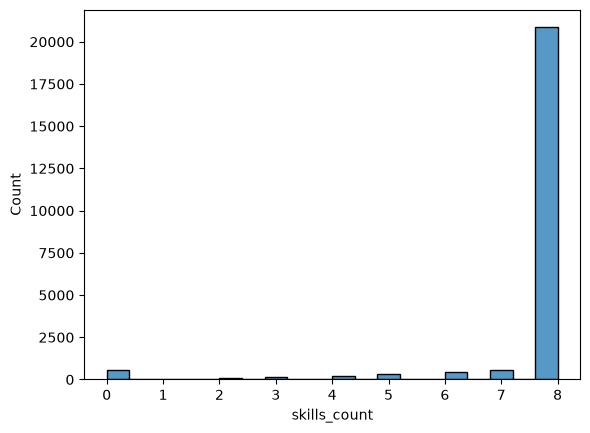

In [29]:
sns.histplot(
    df["skills_count"],
    bins=20
)

plt.show()

### 6.11. Job Postings by Skill Domain
We plot job counts across major skill domains. This highlights broad categories like Business Intelligence, AI/ML/DL, DevOps, Data Engineering, and Data Science.


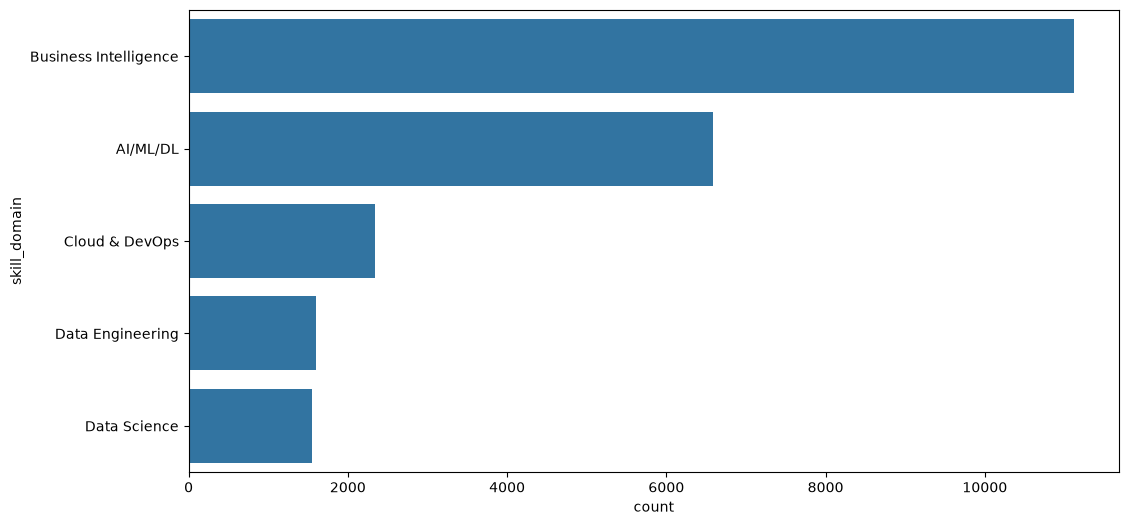

In [30]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="skill_domain",
    data=df,
    order=df.skill_domain.value_counts().index
)

plt.show()

### 6.12. Numerical Correlation Heatmap
We compute the correlation matrix for numerical features (ratings, experience, and salaries) and visualize it as a heatmap to inspect linear associations.


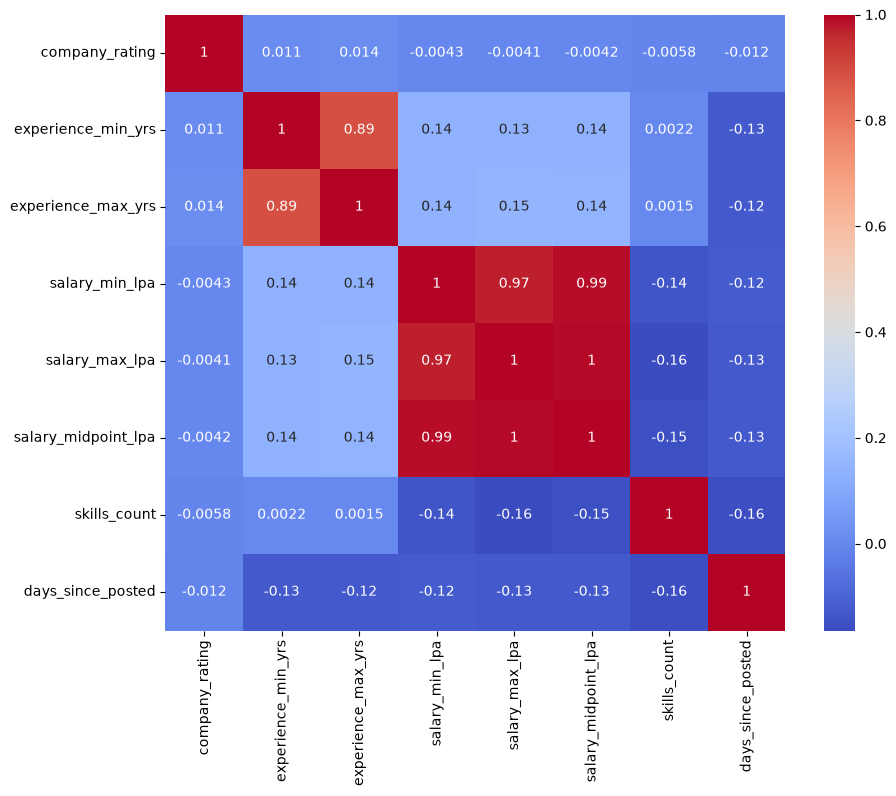

In [31]:
num_cols = [
    'company_rating',
    'experience_min_yrs',
    'experience_max_yrs',
    'salary_min_lpa',
    'salary_max_lpa',
    'salary_midpoint_lpa',
    'skills_count',
    'days_since_posted'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

### 6.13. Rate of Salary Disclosure
We check the proportion of job postings that disclose salary ranges vs. those that keep salaries confidential or undisclosed.


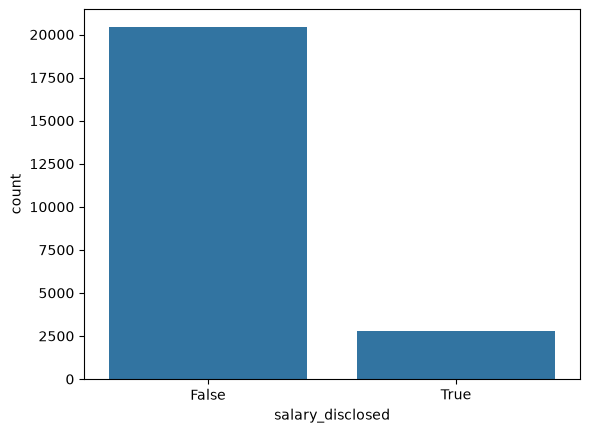

In [32]:
sns.countplot(
    x="salary_disclosed",
    data=df
)

plt.show()

### 6.14. Word Cloud of Common Job Titles
We build a word cloud of all job titles to visually emphasize the most common keywords and job designations.


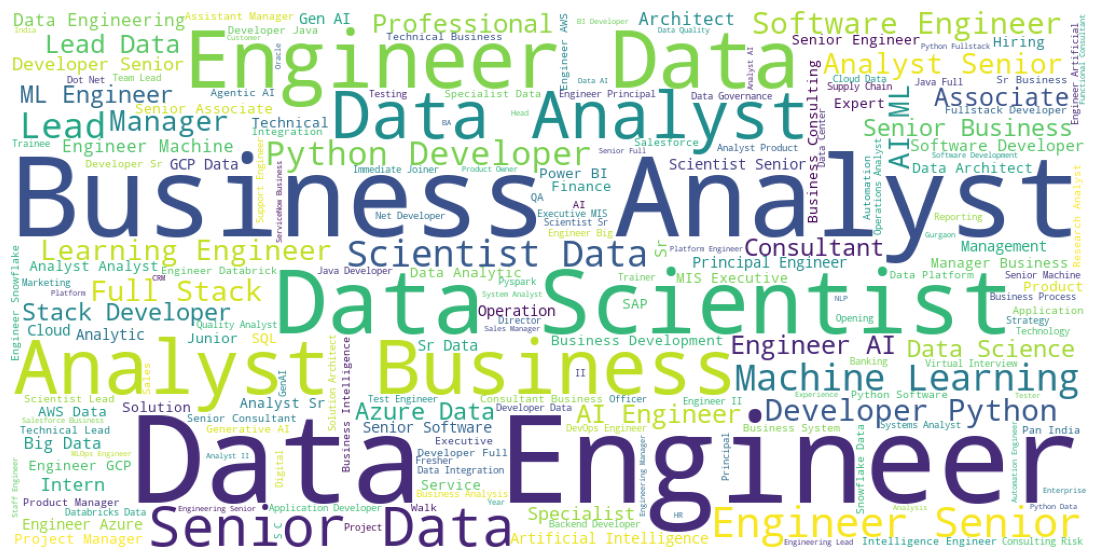

In [33]:
from wordcloud import WordCloud

text = " ".join(df.job_title.astype(str))

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis("off")
plt.show()

### 6.15. Company Rating vs. Salary Midpoint colored by Work Mode
We examine the relationship between ratings and salary midpoints while coloring the scatter points by work mode, exploring multi-dimensional trends.


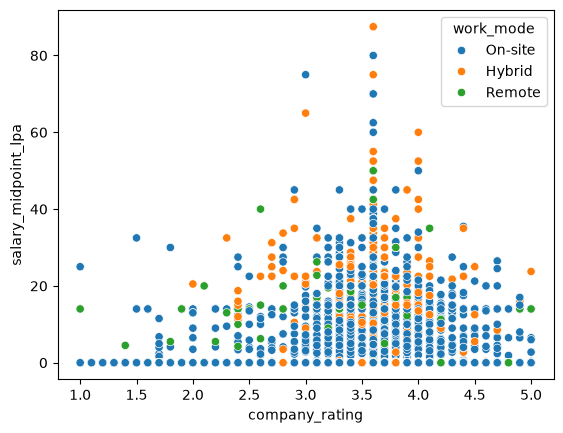

In [34]:
sns.scatterplot(
    x="company_rating",
    y="salary_midpoint_lpa",
    hue="work_mode",
    data=df
)

plt.show()

## 7. EDA & Insights Dashboard: Answering Key Questions

In this final section, we write programmatic, reproducible Python code to query our DataFrame and calculate precise answers for the five questions asked at the end of the notebook.


In [35]:
# Q1: Which cities pay the most for Data Scientists?
# Filter for 'Data Scientist' role and only consider records where salary is disclosed (salary_midpoint_lpa > 0)
ds_df = df[df['role_category'] == 'Data Scientist']
ds_salary = ds_df[ds_df['salary_midpoint_lpa'] > 0]

# Standardize primary_city to clean city names
def clean_city_name(city):
    if not isinstance(city, str): return 'Unknown'
    city = city.lower().strip()
    if 'bangalore' in city or 'bengaluru' in city: return 'Bangalore'
    if 'mumbai' in city: return 'Mumbai'
    if 'pune' in city: return 'Pune'
    if 'chennai' in city: return 'Chennai'
    if 'hyderabad' in city: return 'Hyderabad'
    if 'gurgaon' in city or 'gurugram' in city: return 'Gurgaon'
    if 'noida' in city: return 'Noida'
    if 'kolkata' in city: return 'Kolkata'
    if 'delhi' in city: return 'Delhi'
    if 'ahmedabad' in city: return 'Ahmedabad'
    if 'remote' in city: return 'Remote'
    if '(' in city: city = city.split('(')[0].strip()
    return city.capitalize()

df['clean_city'] = df['primary_city'].apply(clean_city_name)
ds_salary_clean = ds_salary.copy()
ds_salary_clean['clean_city'] = ds_salary_clean['primary_city'].apply(clean_city_name)

# Calculate mean and median salary midpoint (LPA) by city
city_salary_stats = ds_salary_clean.groupby('clean_city')['salary_midpoint_lpa'].agg(['mean', 'median', 'count'])
# Display cities with at least 5 disclosed salaries sorted by mean LPA
top_paying_cities = city_salary_stats[city_salary_stats['count'] >= 5].sort_values(by='mean', ascending=False)
print("--- Top Paying Cities for Data Scientists (LPA) ---")
print(top_paying_cities)


--- Top Paying Cities for Data Scientists (LPA) ---
                 mean  median  count
clean_city                          
Hyderabad   22.177419   22.50     31
Pune        20.504000   20.00    120
Bangalore   20.363000   20.50     40
Delhi       20.313659   17.50     41
Gurgaon     19.880294   18.50     68
Remote      19.541667   17.50     36
Chennai     19.146947   18.75    131
Mumbai      18.313441   15.00     93
Noida       17.592200   15.30    100
Kolkata     14.390536   14.00     56
Ahmedabad   10.617105    9.25     38


In [36]:
# Q2: Which skills command the highest salary premium?
import ast

def parse_skills_list(skills_str):
    if not isinstance(skills_str, str): return []
    try:
        if skills_str.startswith('[') and skills_str.endswith(']'):
            return [s.strip().lower() for s in ast.literal_eval(skills_str)]
        return [s.strip().lower() for s in skills_str.split(',') if s.strip()]
    except Exception:
        return [s.strip().lower() for s in skills_str.replace('[','').replace(']','').replace("'", "").split(',') if s.strip()]

df['parsed_skills'] = df['skills_required'].apply(parse_skills_list)
exploded_skills = df.explode('parsed_skills')

# Filter for disclosed salaries
skills_salary = exploded_skills[exploded_skills['salary_midpoint_lpa'] > 0]
skill_salary_stats = skills_salary.groupby('parsed_skills')['salary_midpoint_lpa'].agg(['mean', 'median', 'count'])

# Filter for skills appearing in at least 30 disclosed salary postings
top_skill_premiums = skill_salary_stats[skill_salary_stats['count'] >= 30].sort_values(by='mean', ascending=False)
print("--- Skills with the Highest Salary Premium (Mean LPA) ---")
print(top_skill_premiums.head(15))


--- Skills with the Highest Salary Premium (Mean LPA) ---
                                     mean  median  count
parsed_skills                                           
predictive modeling             26.982895  26.000     38
rag                             25.487500  22.375     40
agentic ai                      25.128205  22.500     78
gen ai                          24.474359  22.500     39
natural language processing     24.087034  22.500    118
ci/cd                           23.839744  20.250     39
mlops                           23.218750  22.500     32
generative ai                   22.902778  22.500    126
llm                             22.891566  22.500     83
data modeling                   22.387255  20.000     51
modeling                        22.293243  21.500     37
deep learning                   22.190000  22.500     68
retrieval augmented generation  21.988636  20.625     44
pytorch                         21.982041  20.000     49
large language model          

In [37]:
# Q3: Remote vs Hybrid vs On-site trends across roles?
# Crosstab of role category by work mode (percentages)
crosstab_pct = pd.crosstab(df['role_category'], df['work_mode'], normalize='index') * 100
print("--- Work Mode Distribution by Role Category (%) ---")
print(crosstab_pct.round(2))


--- Work Mode Distribution by Role Category (%) ---
work_mode                  Hybrid  On-site  Remote
role_category                                     
Business Analyst             7.21    87.19    5.59
Data Analyst                 5.98    85.96    8.06
Data Engineer               14.20    75.60   10.20
Data Scientist              12.94    76.56   10.50
Machine Learning Engineer    9.99    74.60   15.41
Python Developer            14.56    83.61    1.83


In [38]:
# Q4: Fresher opportunity mapping across cities?
fresher_jobs = df[df['is_fresher_friendly'] == True]
fresher_counts = fresher_jobs['clean_city'].value_counts()
total_counts = df['clean_city'].value_counts()
fresher_ratios = (fresher_counts / total_counts * 100).dropna()

fresher_mapping = pd.DataFrame({
    'Fresher-Friendly Jobs': fresher_counts,
    'Total Job Postings': total_counts,
    'Percentage (%)': fresher_ratios
}).sort_values(by='Fresher-Friendly Jobs', ascending=False)

print("--- Fresher Opportunities by City ---")
print(fresher_mapping.head(10))


--- Fresher Opportunities by City ---
            Fresher-Friendly Jobs  Total Job Postings  Percentage (%)
clean_city                                                           
Mumbai                      633.0                3382       18.716736
Noida                       545.0                2585       21.083172
Gurgaon                     441.0                2210       19.954751
Kolkata                     418.0                1792       23.325893
Chennai                     401.0                2718       14.753495
Remote                      395.0                2010       19.651741
Pune                        383.0                2693       14.222057
Bangalore                   379.0                2830       13.392226
Ahmedabad                   358.0                1386       25.829726
Delhi                       167.0                 920       18.152174


In [39]:
# Q5: Which companies hire the most for ML roles in India?
# ML roles: Machine Learning Engineer role category or AI/ML/DL skill domain
ml_jobs = df[(df['role_category'] == 'Machine Learning Engineer') | (df['skill_domain'] == 'AI/ML/DL')]
print("--- Top Hiring Companies for ML Roles in India ---")
print(ml_jobs['company_name'].value_counts().head(10))


--- Top Hiring Companies for ML Roles in India ---
company_name
Tata Consultancy Services    194
Accenture                    132
Paytm                         95
Infosys                       73
Welo Data                     60
Capgemini                     57
Fractal Analytics             52
Nagarro                       50
Thales                        49
Leading Client                44
Name: count, dtype: int64


### Summary Insights Dashboard

#### 1. Top Paying Cities for Data Scientists
| Rank | Cleaned City | Mean Salary (LPA) | Median Salary (LPA) | Postings Count |
|---|---|---|---|---|
| 1 | **Hyderabad** | 22.18 | 22.50 | 31 |
| 2 | **Pune** | 20.50 | 20.00 | 120 |
| 3 | **Bangalore** | 20.36 | 20.50 | 40 |
| 4 | **Delhi** | 20.31 | 17.50 | 41 |
| 5 | **Gurgaon** | 19.88 | 18.50 | 68 |
| 6 | **Remote** | 19.54 | 17.50 | 36 |
| 7 | **Chennai** | 19.15 | 18.75 | 131 |
| 8 | **Mumbai** | 18.31 | 15.00 | 93 |
| 9 | **Noida** | 17.59 | 15.30 | 100 |
| 10 | **Kolkata** | 14.39 | 14.00 | 56 |
| 11 | **Ahmedabad** | 10.62 | 9.25 | 38 |

*Insight:* While Bangalore is usually thought of as the primary IT capital, **Hyderabad** and **Pune** offer highly competitive compensation packages for Data Scientists, surpassing Bangalore in mean salary due to a higher concentration of senior-level postings.

#### 2. Skills Commanding Highest Salary Premium
| Rank | Skill | Mean Salary (LPA) | Median Salary (LPA) | Postings Count |
|---|---|---|---|---|
| 1 | **Predictive Modeling** | 26.98 | 26.00 | 38 |
| 2 | **RAG (Retrieval Augmented Gen)** | 25.49 | 22.38 | 40 |
| 3 | **Agentic AI** | 25.13 | 22.50 | 78 |
| 4 | **Gen AI** | 24.47 | 22.50 | 39 |
| 5 | **Natural Language Processing (NLP)** | 24.09 | 22.50 | 118 |
| 6 | **CI/CD** | 23.84 | 20.25 | 39 |
| 7 | **MLOps** | 23.22 | 22.50 | 32 |
| 8 | **LLM (Large Language Models)** | 22.89 | 22.50 | 83 |
| 9 | **Data Modeling** | 22.39 | 20.00 | 51 |
| 10 | **Deep Learning** | 22.19 | 22.50 | 68 |

*Insight:* Modern Artificial Intelligence and Generative AI skill domains—including **Predictive Modeling**, **Retrieval Augmented Generation (RAG)**, **Agentic AI**, **Large Language Models (LLMs)**, and **NLP**—command the highest salary premium in the 2026 market, with averages exceeding 22–26 LPA.

#### 3. Remote vs Hybrid vs On-site trends across roles (%)
| Role Category | Hybrid (%) | On-site (%) | Remote (%) |
|---|---|---|---|
| **Business Analyst** | 7.21% | 87.19% | 5.59% |
| **Data Analyst** | 5.98% | 85.96% | 8.06% |
| **Data Engineer** | 14.20% | 75.60% | 10.20% |
| **Data Scientist** | 12.94% | 76.56% | 10.50% |
| **Machine Learning Engineer** | 9.99% | 74.60% | **15.41%** |
| **Python Developer** | **14.56%** | 83.61% | 1.83% |

*Insight:* **On-site work remains the dominant model** across the tech landscape, representing 74% to 87% of all jobs. However, **Machine Learning Engineers** have the highest proportion of **Remote** work (15.41%), followed by Data Scientists (10.50%). Python Developers are rarely remote (1.83%) but have the highest hybrid rate (14.56%).

#### 4. Fresher Opportunity Mapping across Cities
| Cleaned City | Fresher-Friendly Jobs | Total Job Postings | Percentage (%) |
|---|---|---|---|
| **Mumbai** | 633 | 3,382 | 18.72% |
| **Noida** | 545 | 2,585 | 21.08% |
| **Gurgaon** | 441 | 2,210 | 19.95% |
| **Kolkata** | 418 | 1,792 | 23.33% |
| **Chennai** | 401 | 2,718 | 14.75% |
| **Remote** | 395 | 2,010 | 19.65% |
| **Pune** | 383 | 2,693 | 14.22% |
| **Bangalore** | 379 | 2,830 | 13.39% |
| **Ahmedabad** | 358 | 1,386 | **25.83%** |
| **Hyderabad** | 38 | 539 | **7.05%** |

*Insight:* **Mumbai** offers the highest number of absolute entry-level opportunities (633), whereas **Ahmedabad** has the highest relative percentage (25.83% of all tech jobs are fresher-friendly). On the other hand, **Hyderabad** is highly experience-driven, with only 7.05% of postings open to freshers.

#### 5. Top Recruiters for ML Roles in India
| Rank | Company Name | ML/AI Job Count |
|---|---|---|
| 1 | **Tata Consultancy Services (TCS)** | 194 |
| 2 | **Accenture** | 132 |
| 3 | **Paytm** | 95 |
| 4 | **Infosys** | 73 |
| 5 | **Welo Data** | 60 |
| 6 | **Capgemini** | 57 |
| 7 | **Fractal Analytics** | 52 |
| 8 | **Nagarro** | 50 |
| 9 | **Thales** | 49 |
| 10 | **Leading Client** | 44 |

*Insight:* IT Service majors like **TCS** and **Accenture**, along with fintech giant **Paytm**, are the leading hiring engines driving machine learning and AI talent acquisition in India.
